In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [7]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7395575/sum_neutron_planarsource_wafers.root")
tree = file["Primary"]
tree5 = file["Hits"]

df = tree.arrays(library="pd")
df5 = tree5.arrays(library="pd")

merged_df5 = df.merge(df5, on=["EventID"], how="inner")


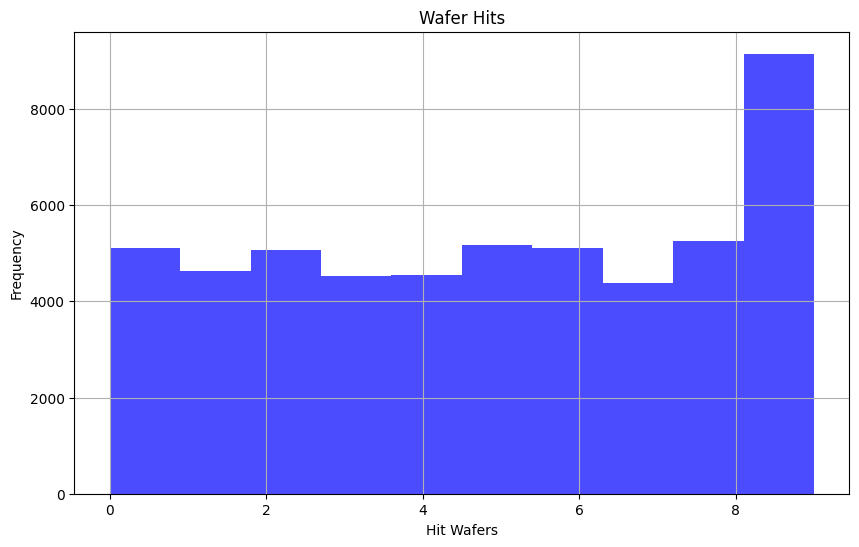

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(df5['CopyNumber'], bins=10, color='blue', alpha=0.7)
plt.title('Wafer Hits')
plt.xlabel('Hit Wafers')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("wafer_hits.pdf")
plt.show()

In [4]:
#look at number of unique wafers hit in the event 
df5['numberWafers'] = df5.groupby('EventID')['CopyNumber'].transform('nunique')
print(df5)

df = df.merge(df5.groupby('EventID')['CopyNumber'].nunique()
                .reset_index(name='numberWafers'), on='EventID', how='left')
df['numberWafers'] = df['numberWafers'].fillna(0).astype(int)
print(df)

        EventID  TrackID       PDGCode  ParticleName  ParticleDefinition  \
0         140.0    299.0  1.000020e+09         alpha               alpha   
1         140.0    298.0  1.000010e+09        triton              triton   
2         225.0   2417.0  2.200000e+01         gamma               gamma   
3         225.0   2436.0  1.100000e+01            e-                  e-   
4         225.0   2435.0  1.100000e+01            e-                  e-   
...         ...      ...           ...           ...                 ...   
52907  999890.0    515.0  1.100000e+01            e-                  e-   
52908  999890.0    514.0  1.100000e+01            e-                  e-   
52909  999890.0    513.0  1.100000e+01            e-                  e-   
52910  999890.0    502.0  1.100000e+01            e-                  e-   
52911  999955.0    563.0  1.100000e+01            e-                  e-   

           Edep   PositionX  PositionY  PositionZ  MomentumX  MomentumY  \
0      2.055

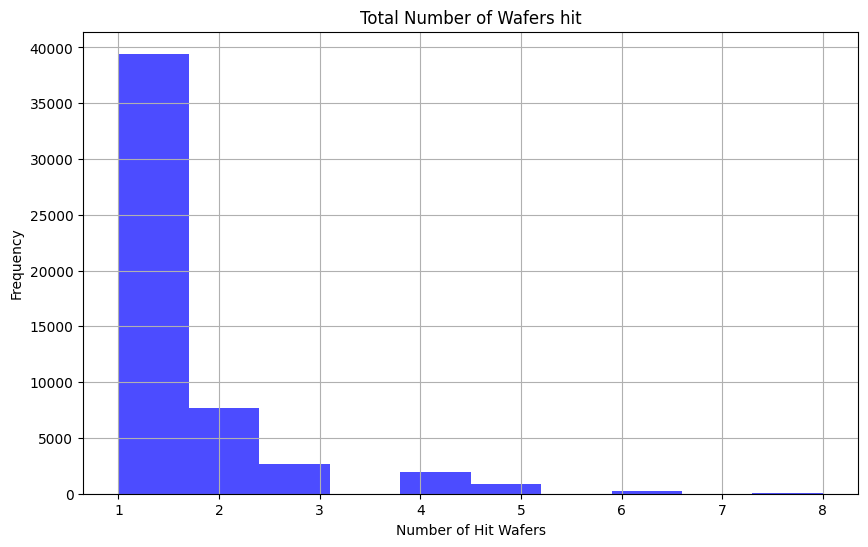

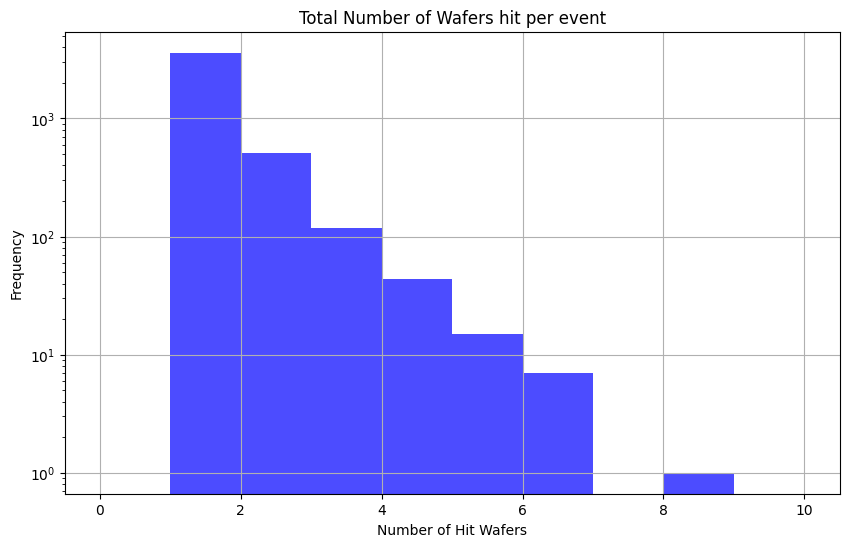

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df5['numberWafers'], color='blue', alpha=0.7)
plt.title('Total Number of Wafers hit')
plt.xlabel('Number of Hit Wafers')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("total_wafers_hit.pdf")
plt.show()

mask = df['numberWafers'] > 0 
masked_df = df[mask]

plt.figure(figsize=(10, 6))
plt.hist(masked_df['numberWafers'], bins=10, range=(0,10), color='blue', alpha=0.7)
plt.title('Total Number of Wafers hit per event')
plt.xlabel('Number of Hit Wafers')
plt.ylabel('Frequency')
plt.grid()
plt.yscale('log')
plt.savefig("total_wafers_hit_eventlevel.pdf")
plt.show()
